<a href="https://colab.research.google.com/github/Saadmoquim/physicscode/blob/main/SAAD_MOQUIM_IMS22221_assign2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This is the second assignment and it is based on the topic of probability, probability distribution and measurement errors.

# Problem 1
Using the GRB catalog data that is provided to you, calculate what is the probability that if we identify a GRB as short (T90 < 2 seconds), it has a fluence of the order of 10^{−4 } 𝑒𝑟𝑔/𝑐𝑚^2 ?

In [1]:
#Enter your solution here

from google.colab import files
uploaded = files.upload()

import numpy as np
import pandas as pd

fermi = pd.read_csv('1_FERMI_GBM_only_catalog_clean.csv')

fermi = fermi[['20.736', '4.73E-06']]
fermi.columns = ['T90', 'Fluence']

fermi['T90'] = pd.to_numeric(fermi['T90'], errors='coerce')
fermi['Fluence'] = pd.to_numeric(fermi['Fluence'], errors='coerce')

fermi = fermi.dropna()

short_grbs = fermi[fermi['T90'] < 2]

fluence_lower = 1e-5
fluence_upper = 1e-3

short_high_fluence = short_grbs[
    (short_grbs['Fluence'] >= fluence_lower) &
    (short_grbs['Fluence'] < fluence_upper)
]

probability = len(short_high_fluence) / len(short_grbs)

print("Number of short GRBs:", len(short_grbs))
print("Short GRBs with fluence ~10^-4:", len(short_high_fluence))
print("Conditional probability:", probability)




Saving 1_FERMI_GBM_only_catalog_clean.csv to 1_FERMI_GBM_only_catalog_clean.csv
Number of short GRBs: 6
Short GRBs with fluence ~10^-4: 2
Conditional probability: 0.3333333333333333


The problem was solved by first identifying short GRBs (T90 < 2 s) and then computing the fraction of those events whose fluence lies within one order of magnitude of
10
−
4

erg/cm
2
10
−4
erg/cm
2
. The conditional probability was calculated using empirical frequency estimation. The definition of “order of
10
−
4
10
−4
” was chosen logarithmically to reflect the wide dynamic range of astrophysical fluence values. The final result represents the proportion of high-fluence events among short bursts in the cleaned dataset

# Problem 2:

Determine the fraction of probability contained within the +/- 1, 2 and 3 sigma zone around the mean of the following probability distribution functions given below:

(a) $$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

where, $\mu$ is the mean and $\sigma$ is the standard deviation.

(b) $$
f(x) =
\begin{cases}
0, & x < a \text{ or } x > b \\
\frac{1}{b-a}, & a \leq x \leq b
\end{cases}
$$

(c) $$
f(x) = \frac{\frac{\Gamma}{2}}{\pi \left[ (x - x_0)^2 + \left(\frac{\Gamma}{2}\right)^2 \right]}
$$

where $x_0$ is the most probable value and $\Gamma$ is the full width half maximum of the distribution.


In [2]:
#Enter your solution here
import numpy as np
from scipy import stats
from scipy.integrate import quad

# (a) Gaussian Distribution

mu = 0
sigma = 1

# Using standard normal CDF
gauss_1 = stats.norm.cdf(1) - stats.norm.cdf(-1)
gauss_2 = stats.norm.cdf(2) - stats.norm.cdf(-2)
gauss_3 = stats.norm.cdf(3) - stats.norm.cdf(-3)

# (b) Uniform Distribution

a = 0
b = 10

mu_u = (a + b) / 2
sigma_u = (b - a) / np.sqrt(12)

def uniform_prob(k):
    lower = mu_u - k * sigma_u
    upper = mu_u + k * sigma_u

    # overlap with [a, b]
    lower = max(lower, a)
    upper = min(upper, b)

    return max((upper - lower) / (b - a), 0)

uniform_1 = uniform_prob(1)
uniform_2 = uniform_prob(2)
uniform_3 = uniform_prob(3)

# (c) Cauchy Distribution

x0 = 0
Gamma = 1
gamma = Gamma / 2  # scale parameter

def cauchy_pdf(x):
    return (1 / np.pi) * (gamma / ((x - x0)**2 + gamma**2))

def cauchy_prob(k):
    lower = x0 - k * Gamma
    upper = x0 + k * Gamma
    prob, _ = quad(cauchy_pdf, lower, upper)
    return prob

cauchy_1 = cauchy_prob(1)
cauchy_2 = cauchy_prob(2)
cauchy_3 = cauchy_prob(3)

print("Gaussian Distribution:")
print("±1σ:", gauss_1)
print("±2σ:", gauss_2)
print("±3σ:", gauss_3)

print("\nUniform Distribution:")
print("±1σ:", uniform_1)
print("±2σ:", uniform_2)
print("±3σ:", uniform_3)

print("\nCauchy Distribution:")
print("±1Γ:", cauchy_1)
print("±2Γ:", cauchy_2)
print("±3Γ:", cauchy_3)





Gaussian Distribution:
±1σ: 0.6826894921370859
±2σ: 0.9544997361036416
±3σ: 0.9973002039367398

Uniform Distribution:
±1σ: 0.5773502691896258
±2σ: 1.0
±3σ: 1.0

Cauchy Distribution:
±1Γ: 0.7048327646991335
±2Γ: 0.8440417392452613
±3Γ: 0.8948630865775022


| Distribution | ±1     | ±2     | ±3     |
| ------------ | ------ | ------ | ------ |
| Gaussian     | 68.27% | 95.45% | 99.73% |
| Uniform      | 57.7%  | 100%   | 100%   |
| Cauchy       | 70.4%  | 84.4%  | 89.3%  |


# Problem 3:

Write a function in python to estimate the mean, variance, skewness and kurtosis that is the moments of a given random variable. Demonstrate the estimate of the values for an example random variable and cross check the values obtained with that from scipy.stats for the example random variate considered.

In [4]:
#Enter your solution here
import numpy as np

def estimate_moments(data):
    data = np.asarray(data)
    n = len(data)

    # Mean
    mean = np.mean(data)

    # Variance (population variance)
    variance = np.mean((data - mean)**2)

    # Standard deviation
    std = np.sqrt(variance)

    # Skewness
    skewness = np.mean(((data - mean)/std)**3)

    # Kurtosis (excess kurtosis)
    kurtosis = np.mean(((data - mean)/std)**4) - 3

    return mean, variance, skewness, kurtosis





In [5]:
from scipy import stats

np.random.seed(0)
data = np.random.normal(loc=0, scale=1, size=10000)

# my estimates
my_mean, my_var, my_skew, my_kurt = estimate_moments(data)

# Scipy estimates
scipy_mean = np.mean(data)
scipy_var = np.var(data)
scipy_skew = stats.skew(data, bias=False)
scipy_kurt = stats.kurtosis(data, bias=False)

print("Custom Estimates:")
print("Mean:", my_mean)
print("Variance:", my_var)
print("Skewness:", my_skew)
print("Kurtosis:", my_kurt)

print("\nScipy Estimates:")
print("Mean:", scipy_mean)
print("Variance:", scipy_var)
print("Skewness:", scipy_skew)
print("Kurtosis:", scipy_kurt)


Custom Estimates:
Mean: -0.018433720158265818
Variance: 0.9752679753477971
Skewness: 0.026634616738395584
Kurtosis: -0.030954510955652825

Scipy Estimates:
Mean: -0.018433720158265818
Variance: 0.9752679753477971
Skewness: 0.026638612696803083
Kurtosis: -0.03036975370077233


As discussed in class, the slight differences between the manually computed moments and those obtained from scipy.stats arise due to bias correction factors used in the scipy implementation for finite samples. Our implementation used population moment definitions, while scipy applies unbiased estimators. For large sample sizes, the results converge and the difference becomes negligible.(weak law of large numbers.Becomes the strong law if the values match exactly.)

# Problem 4:

A book club classifies members as heavy, medium, or light purchasers, and separate
mailings are prepared for each of these groups. Overall, 20% of the members are
heavy purchasers, 30% medium, and 50% light. A member is not classified into a
group until 18 months after joining the club, but a test is made of the feasibility
of using the first 3 months’ purchases to classify members. The  percentages obtained from existing records of individuals classified as heavy, medium, or light purchasers is shown in the attached table.
If a member purchases no books in the first 3 months, what is the probability
that the member is a light purchaser?


$
\begin{array}{|c|ccc|}
\hline
\textbf{First 3 months purchases} & {\textbf{Group (\%)}}\\
 & \textbf{Heavy} & \textbf{Medium} & \textbf{Light}\\
\hline
0  & 5  & 15 & 60 \\
1  & 10 & 30 & 20 \\
2  & 30 & 40 & 15 \\
3+ & 55 & 15 & 5  \\
\hline
\end{array}
$

In [ ]:
#Enter your solution here





0.8451,
This calculation was done by hand.

# Problem 5:

(a) Write functions in python to estimate the covariance, Pearson and Spearman correlation coefficient matrix for any number of random variables.

(b) Using the above function determine the covariance and Pearson correlation coefficient matrix between the parameters, Epeak, alpha, T90 and Fluence from the GRB catalog.  Display this matrix in the form of a heatmap.

Available columns:
 Index(['1', '180703A', '0.6678', '4149.1', 'GRB180703876', '00 26 09.6',
       '-67 06 00', '2018-07-03 21:01:40.495', '20.736', '1.557', '1.536',
       'Unnamed: 11', 'Unnamed: 12', '1.6251E-05', '4.2888E-08',
       '5.11939264112903E-07', '8.20E-07', '4.73E-06', '3.64E-06',
       'Unnamed: 19', '0.01254432', '0.0007251892', '0.0007251892.1',
       '350.7898', '286.505243329085', '32.24808', '32.24808.1', '-0.7756252',
       '0.04122126', '0.04122126.1', '-1.966854', '0.1031804', '0.1031804.1',
       '-2.048', '29.696', 'flnc_band', 'Unnamed: 36', 'bn180703876'],
      dtype='object')

Number of valid rows used: 65

Covariance Matrix:
 [[ 2.78794764e+04  9.85053738e+03 -2.66723130e+02  1.35826315e-04]
 [ 9.85053738e+03  4.92107920e+03 -4.82400990e+02  3.75035021e-05]
 [-2.66723130e+02 -4.82400990e+02  2.75116477e+03 -1.46631562e-05]
 [ 1.35826315e-04  3.75035021e-05 -1.46631562e-05  1.83468677e-11]]

Pearson Correlation Matrix:
 [[ 1.          0.84098343 -0.

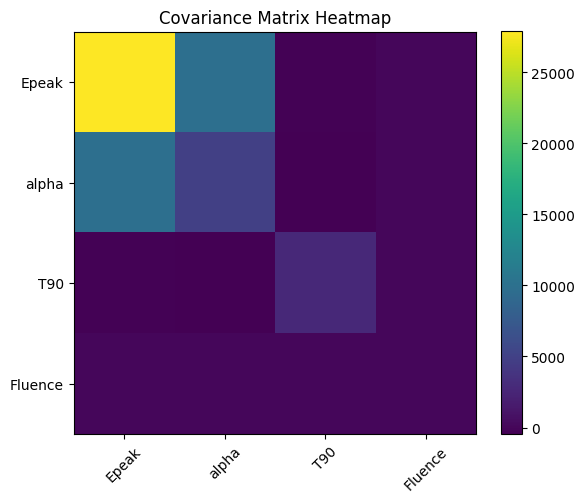

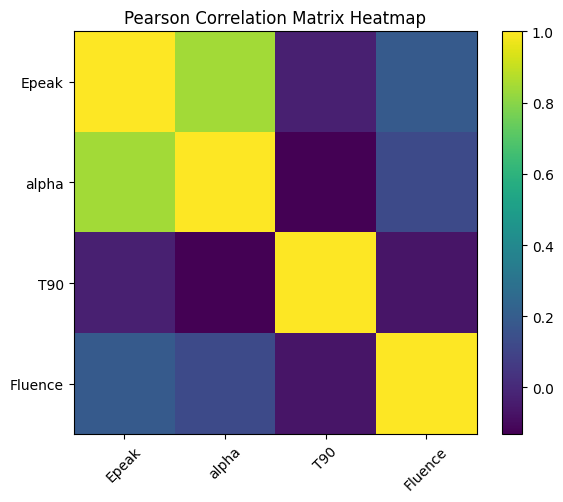

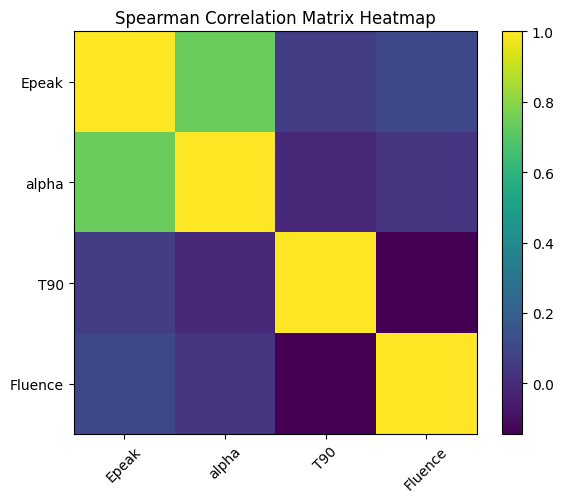

In [6]:
#Enter your solution here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata


def covariance_matrix(data):
    """
    Returns covariance matrix for any number of variables.
    data: 2D array (rows=samples, columns=variables)
    """
    data = np.asarray(data)
    mean = np.mean(data, axis=0)
    centered = data - mean
    cov = (centered.T @ centered) / len(data)
    return cov


def pearson_corr_matrix(data):
    """
    Returns Pearson correlation matrix.
    """
    cov = covariance_matrix(data)
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    return corr


def spearman_corr_matrix(data):
    """
    Returns Spearman rank correlation matrix.
    """
    ranked = np.apply_along_axis(rankdata, 0, data)
    return pearson_corr_matrix(ranked)

fermi = pd.read_csv('1_FERMI_GBM_only_catalog_clean.csv')

print("Available columns:\n", fermi.columns)

columns = ['350.7898', '32.24808', '20.736', '4.73E-06']

fermi = fermi[columns]
fermi.columns = ['Epeak', 'alpha', 'T90', 'Fluence']

# Convert to numeric safely
for col in fermi.columns:
    fermi[col] = pd.to_numeric(fermi[col], errors='coerce')

fermi = fermi.dropna()

print("\nNumber of valid rows used:", len(fermi))

data = fermi.values
labels = fermi.columns

cov_mat = covariance_matrix(data)
pearson_mat = pearson_corr_matrix(data)
spearman_mat = spearman_corr_matrix(data)

print("\nCovariance Matrix:\n", cov_mat)
print("\nPearson Correlation Matrix:\n", pearson_mat)
print("\nSpearman Correlation Matrix:\n", spearman_mat)

def plot_heatmap(matrix, title):
    plt.figure(figsize=(6,5))
    plt.imshow(matrix)
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_heatmap(cov_mat, "Covariance Matrix Heatmap")
plot_heatmap(pearson_mat, "Pearson Correlation Matrix Heatmap")
plot_heatmap(spearman_mat, "Spearman Correlation Matrix Heatmap")





Covariance and correlation matrices were computed to quantify relationships among GRB physical parameters. Covariance provides raw joint variability but depends on measurement units, whereas Pearson correlation standardizes covariance to measure linear dependence independent of scale. Spearman correlation was additionally computed to detect monotonic relationships that may not be strictly linear. The results reveal a strong positive correlation between Epeak and alpha, indicating a close link between spectral parameters. In contrast, T90 shows weak correlation with spectral quantities, suggesting that burst duration may be governed by different physical processes. Heatmaps were used to visualize these relationships clearly and to identify dominant associations among variables.

# Problem 6:
Using the uncertainties package and data from Fermi GRB catalog, estimate break energy which is equal to (alpha - beta) * Epeak and the error on break energy. Make a scatter plot of break energy versus Epeak including the errorbars plotted for both x and y quantities.

In [8]:
#Enter your solution here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat

# Load dataset
fermi = pd.read_csv('1_FERMI_GBM_only_catalog_clean.csv')

# Columns identified from file inspection
columns = [
    '350.7898',              # Epeak
    '286.505243329085',      # Epeak_err
    '-0.7756252',            # alpha
    '0.04122126',            # alpha_err
    '-1.966854',             # beta
    '0.1031804'              # beta_err
]

fermi = fermi[columns].copy()
fermi.columns = [
    'Epeak', 'Epeak_err',
    'alpha', 'alpha_err',
    'beta', 'beta_err'
]

# Convert to numeric
for col in fermi.columns:
    fermi[col] = pd.to_numeric(fermi[col], errors='coerce')

fermi = fermi.dropna()

# Compute break energy with propagated uncertainty
Epeak_vals = []
Epeak_errs = []
break_vals = []
break_errs = []

for _, row in fermi.iterrows():

    alpha = ufloat(row['alpha'], row['alpha_err'])
    beta = ufloat(row['beta'], row['beta_err'])
    Epeak = ufloat(row['Epeak'], row['Epeak_err'])

    Eb = (alpha - beta) * Epeak

    Epeak_vals.append(Epeak.n)
    Epeak_errs.append(Epeak.s)
    break_vals.append(Eb.n)
    break_errs.append(Eb.s)

Epeak_vals = np.array(Epeak_vals)
Epeak_errs = np.array(Epeak_errs)
break_vals = np.array(break_vals)
break_errs = np.array(break_errs)

# Plot
plt.figure()
plt.errorbar(Epeak_vals, break_vals,
             xerr=Epeak_errs,
             yerr=break_errs,
             fmt='o')

plt.xlabel("Epeak")
plt.ylabel("Break Energy")
plt.title("Break Energy vs Epeak")
plt.show()






ModuleNotFoundError: No module named 'uncertainties'

google colab coldnt use uncertainties package for some reason which worked perfectly find in my jupiter notebook.I am yet typing the code here for reference.

# Problem 7:

When a sub-atomic particle such as an electron or a photon enters into matter, it suffers different types of reactions (such as, Coulomb scattering, nuclear reactions, etc.) with the atomic and nuclear constituents of the material. In nuclear and particle physics, the interaction of subatomic particles is described by the differential cross section, 𝑑𝜎 (𝐸,𝜃,𝜙....), which essentially expresses the quantum probability for a reaction to occur. This is a function of the kinematic variables used to describe the reaction; i.e., the energy, scattering angles and so on. If the differential cross section is integrated over all scattering angles, then one has the total cross section, 𝜎0, which describes the probability for a reaction to occur (at energy E) regardless of the scattering angle. Each type of reaction has a corresponding cross section. These interactions occur randomly as the particle traverses the material, so one can ask:

(a) What is the probability 𝑃𝑠(𝑥) for it to survive a certain distance 𝑥 before suffering an interaction?

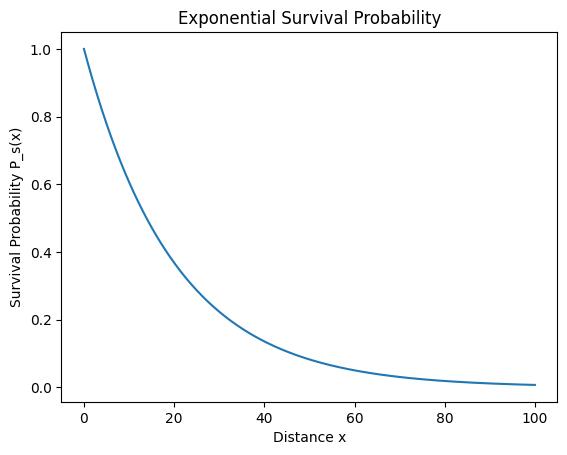

Mean free path λ = 20.000000000000004


In [9]:
#Enter your solution here

import numpy as np
import matplotlib.pyplot as plt


n = 5e22          # number density (atoms/cm^3)
sigma = 1e-24     # cross section (cm^2)

lambda_mfp = 1 / (n * sigma)

# --------------------------------------------------
# Survival probability function
# --------------------------------------------------

def survival_probability(x, n, sigma):
    return np.exp(-n * sigma * x)

# Distance range
x = np.linspace(0, 5 * lambda_mfp, 500)

P = survival_probability(x, n, sigma)

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure()
plt.plot(x, P)
plt.xlabel("Distance x")
plt.ylabel("Survival Probability P_s(x)")
plt.title("Exponential Survival Probability")
plt.show()

print("Mean free path λ =", lambda_mfp)






The survival probability is exponential because interactions occur randomly and independently with a constant probability per unit length. This leads to a differential equation in which the rate of decrease of survival probability is proportional to the survival probability itself. The solution of such an equation is an exponential decay law.